In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")

In [2]:
DATA_PATH = "../data/raw/data.csv"

df = pd.read_csv(DATA_PATH)

df.head()

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


In [18]:
REQUIRED_COLUMNS = [
    "CustomerId",
    "TransactionId",
    "Amount",
    "Value",
    "TransactionStartTime"
]

missing_columns = [
    col for col in REQUIRED_COLUMNS
    if col not in df.columns
]

assert len(missing_columns) == 0, (
    f"Missing required columns: {missing_columns}"
)

print("All required columns are present.")

All required columns are present.


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 95662
Columns: 16
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  object 
 1   BatchId               95662 non-null  object 
 2   AccountId             95662 non-null  object 
 3   SubscriptionId        95662 non-null  object 
 4   CustomerId            95662 non-null  object 
 5   CurrencyCode          95662 non-null  object 
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  object 
 8   ProductId             95662 non-null  object 
 9   ProductCategory       95662 non-null  object 
 10  ChannelId             95662 non-null  object 
 11  Amount                95662 non-null  float64
 12  Value                 95662 non-null  int64  
 13  TransactionStartTime  95662 non-null  object 
 14  PricingStrategy       95662 non-null  int64  


In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
TransactionId,95662,95662,TransactionId_35670,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BatchId,95662,94809,BatchId_67019,28,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AccountId,95662,3633,AccountId_4841,30893,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SubscriptionId,95662,3627,SubscriptionId_3829,32630,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CustomerId,95662,3742,CustomerId_7343,4091,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CurrencyCode,95662,1,UGX,95662,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CountryCode,95662.0,NaN,NaN,NaN,256.0,0.0,256.0,256.0,256.0,256.0,256.0
ProviderId,95662,6,ProviderId_4,38189,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ProductId,95662,23,ProductId_6,32635,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ProductCategory,95662,9,financial_services,45405,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Missing Values

In [5]:
missing_values = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": df.isnull().mean() * 100
}).sort_values(by="missing_count", ascending=False)

missing_values

,missing_count,missing_percentage
TransactionId,0,0.0
BatchId,0,0.0
AccountId,0,0.0
SubscriptionId,0,0.0
CustomerId,0,0.0
CurrencyCode,0,0.0
CountryCode,0,0.0
ProviderId,0,0.0
ProductId,0,0.0
ProductCategory,0,0.0


Duplicate Rows

In [6]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


Convert Transaction Time

In [7]:
df["TransactionStartTime"] = pd.to_datetime(df["TransactionStartTime"])

df["TransactionHour"] = df["TransactionStartTime"].dt.hour
df["TransactionDay"] = df["TransactionStartTime"].dt.day
df["TransactionMonth"] = df["TransactionStartTime"].dt.month
df["TransactionYear"] = df["TransactionStartTime"].dt.year

df[["TransactionStartTime", "TransactionHour", "TransactionDay", "TransactionMonth", "TransactionYear"]].head()

,TransactionStartTime,TransactionHour,TransactionDay,TransactionMonth,TransactionYear
0,2018-11-15 02:18:49+00:00,2,15,11,2018
1,2018-11-15 02:19:08+00:00,2,15,11,2018
2,2018-11-15 02:44:21+00:00,2,15,11,2018
3,2018-11-15 03:32:55+00:00,3,15,11,2018
4,2018-11-15 03:34:21+00:00,3,15,11,2018


In [19]:
def plot_numeric_distribution(df, column):
    """
    Plot histogram and KDE for numerical features.
    """
    assert column in df.columns, f"{column} not found"

    plt.figure(figsize=(8, 4))
    sns.histplot(df[column], kde=True, bins=40)
    plt.title(f"Distribution of {column}")
    plt.show()


def plot_boxplot(df, column):
    """
    Plot boxplot for outlier inspection.
    """
    assert column in df.columns, f"{column} not found"

    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[column])
    plt.title(f"Boxplot of {column}")
    plt.show()


def plot_top_categories(df, column, top_n=10):
    """
    Plot most frequent categories.
    """
    assert column in df.columns, f"{column} not found"

    plt.figure(figsize=(10, 4))

    (
        df[column]
        .value_counts()
        .head(top_n)
        .plot(kind="bar")
    )

    plt.title(column)
    plt.show()

Numerical Feature Distributions

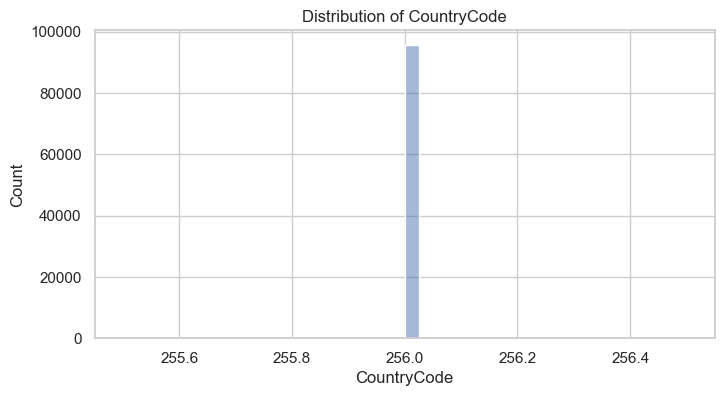

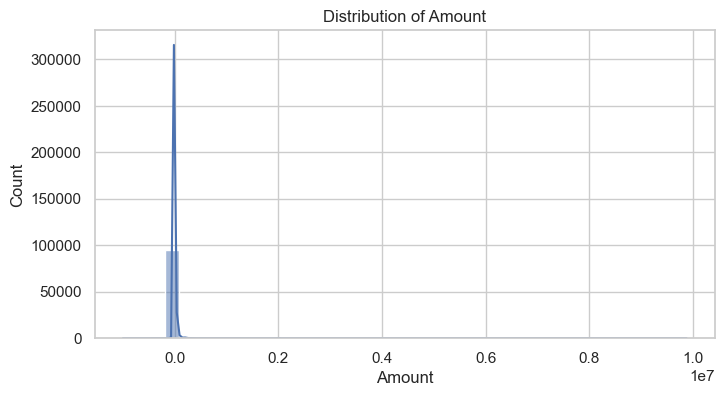

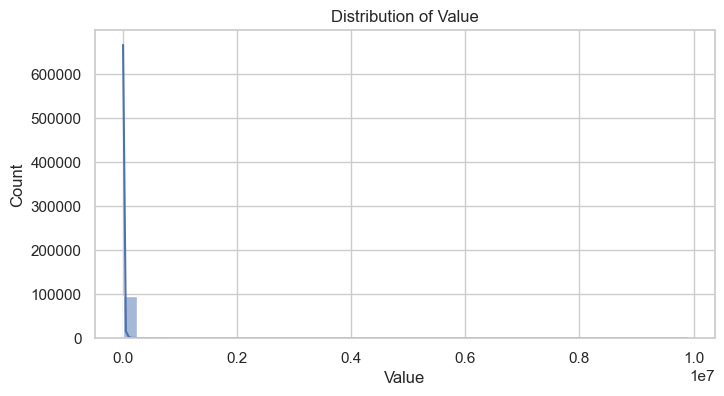

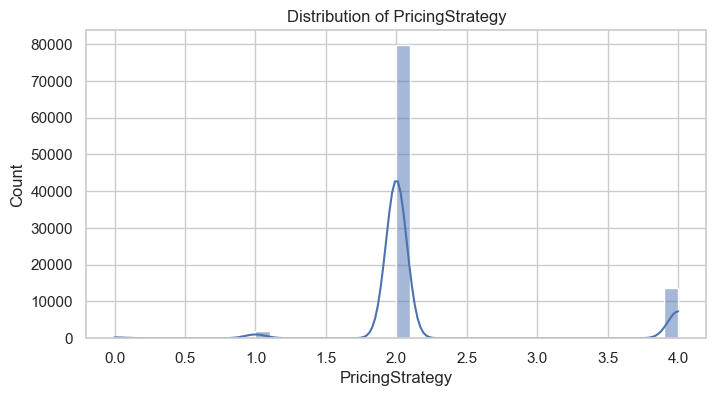

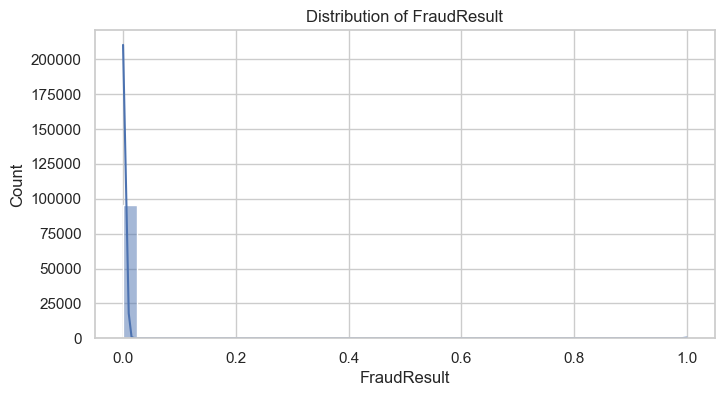

In [20]:
for col in numeric_cols:
    plot_numeric_distribution(df, col)

Outliers

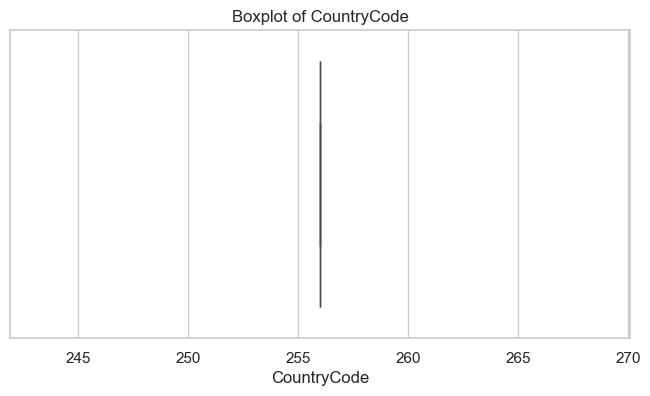

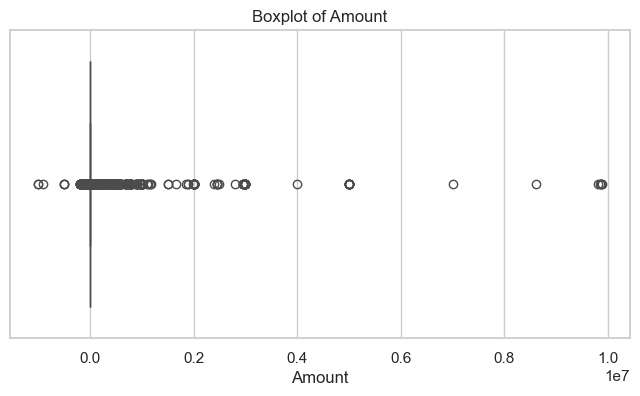

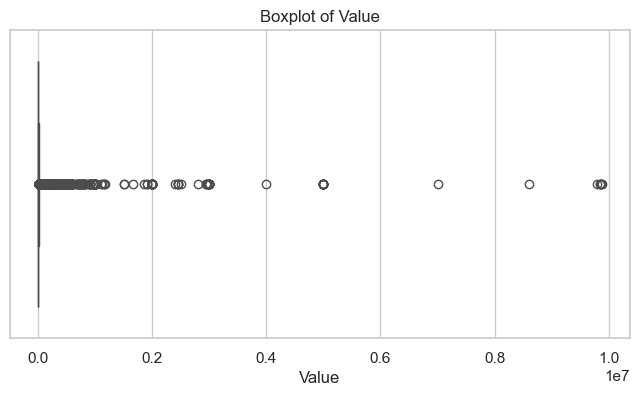

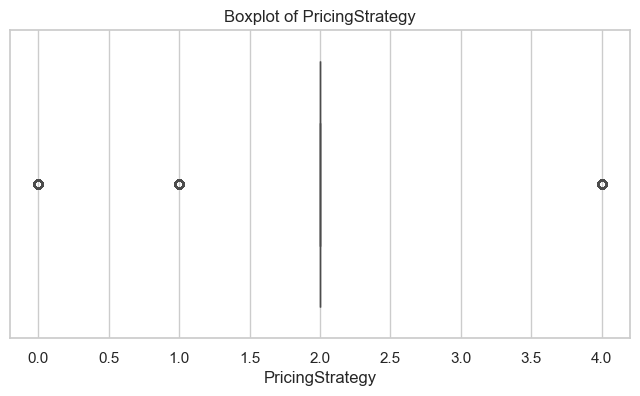

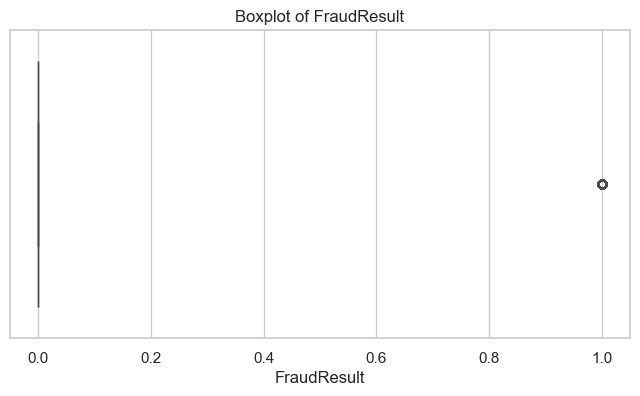

In [21]:
for col in numeric_cols:
    plot_boxplot(df, col)

Categorical Feature Distributions

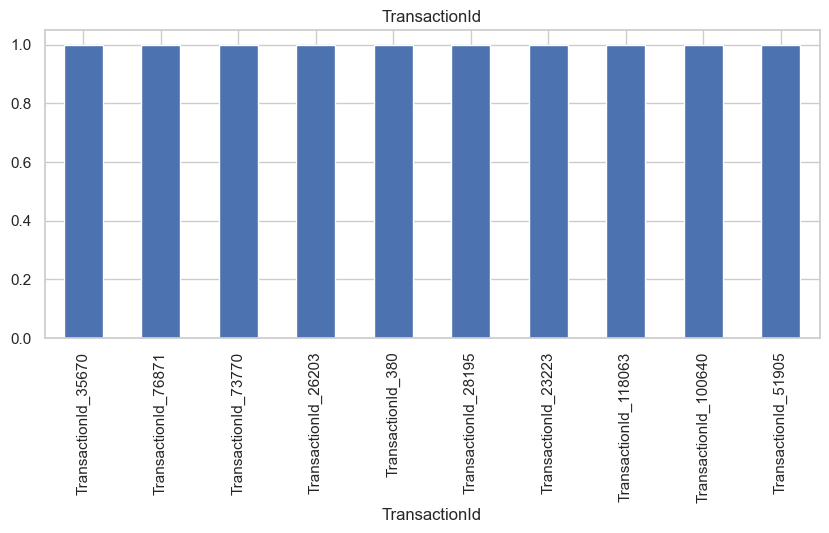

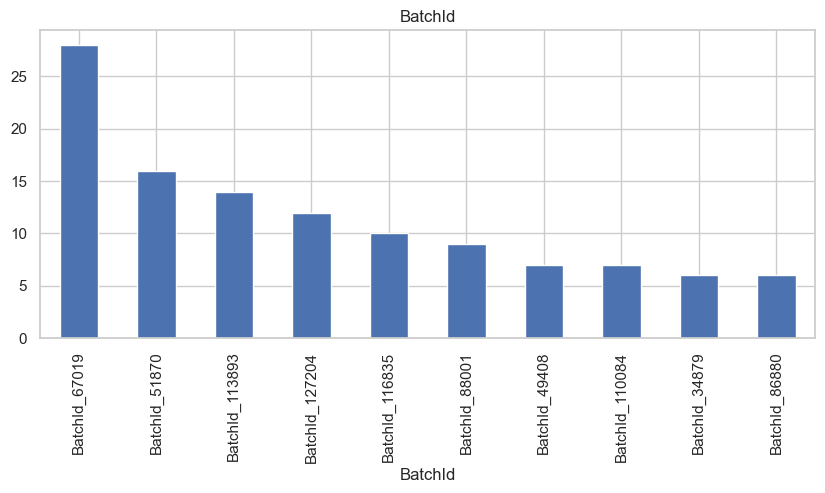

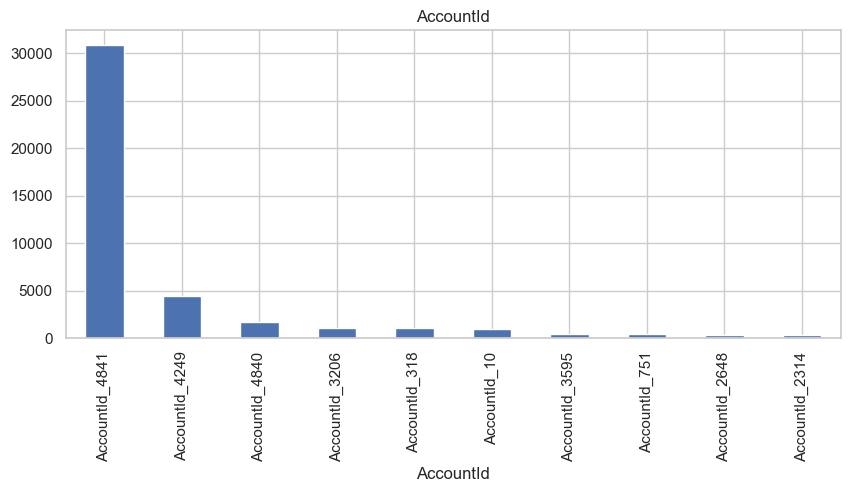

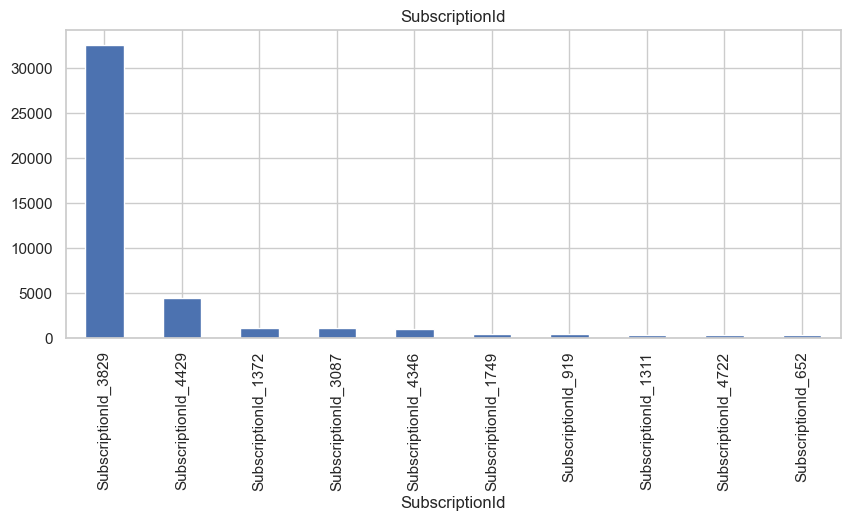

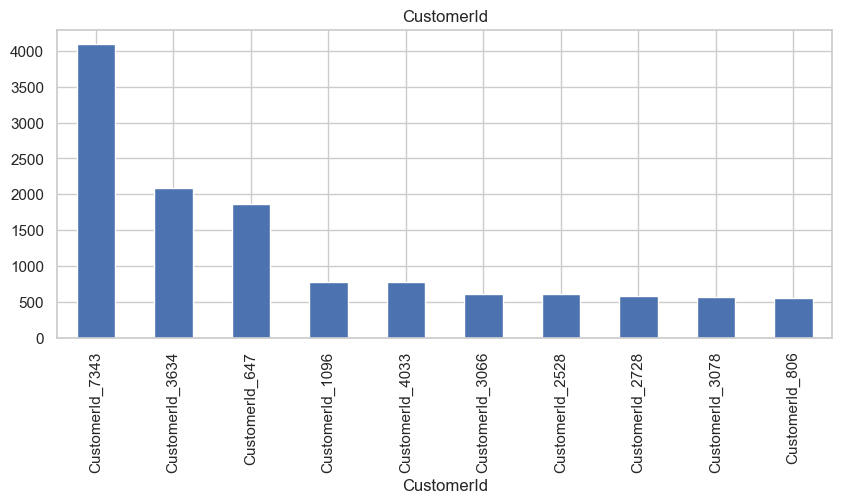

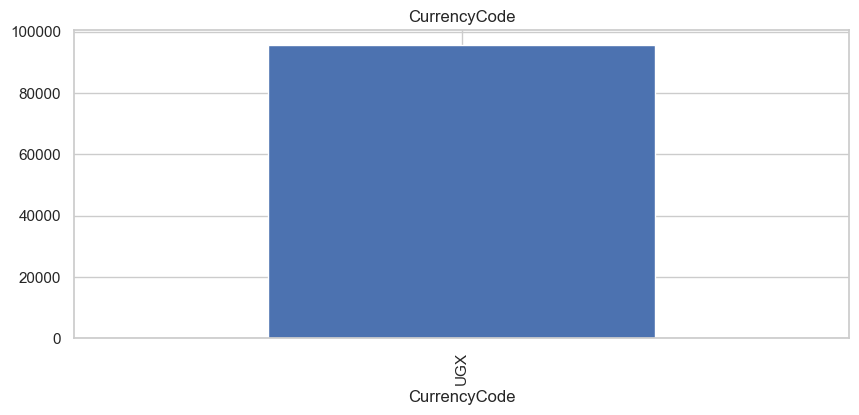

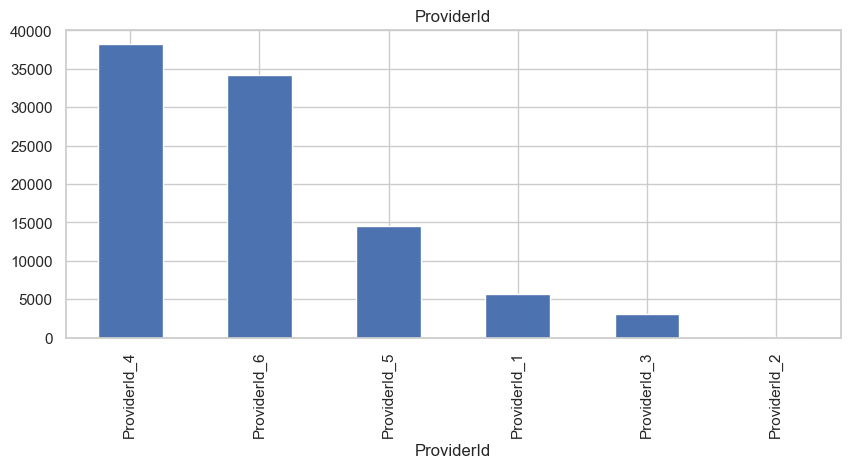

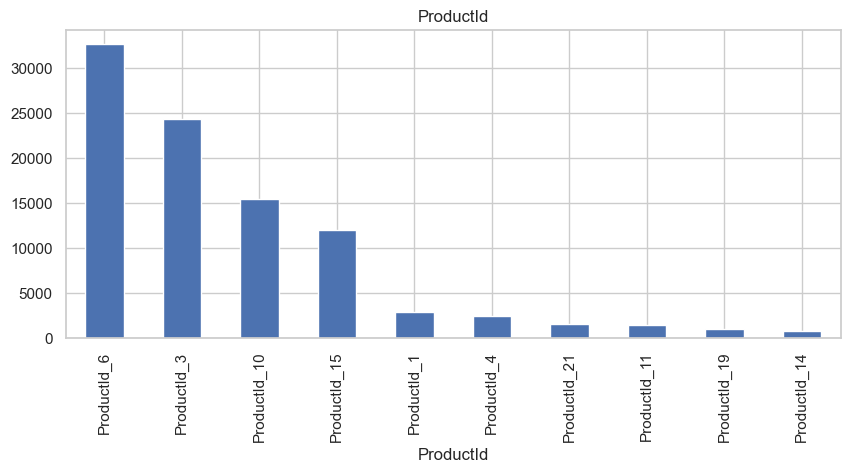

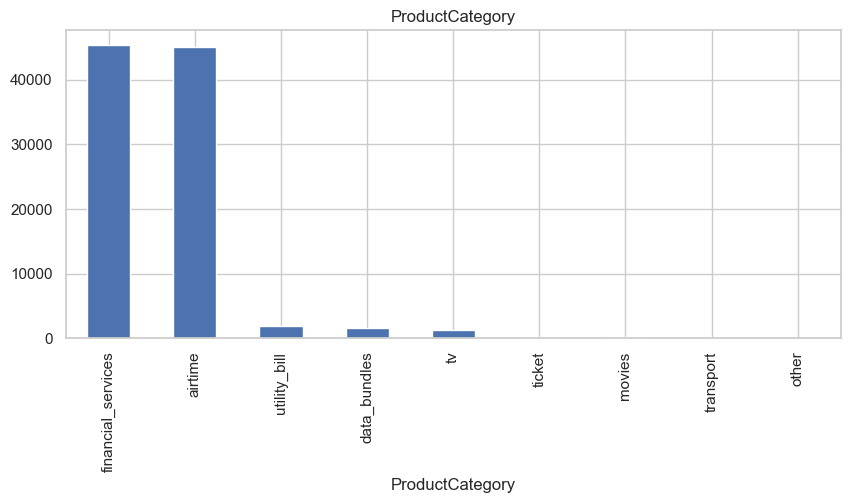

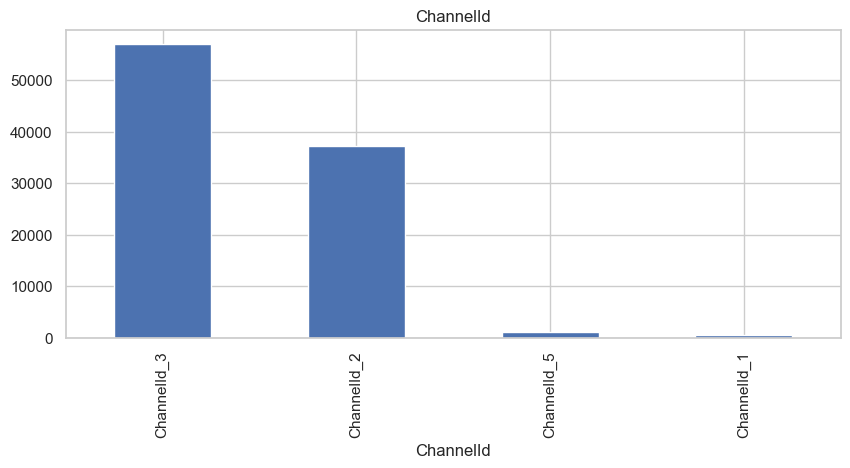

In [22]:
for col in categorical_cols:
    plot_top_categories(df, col)

Corelation Analysis

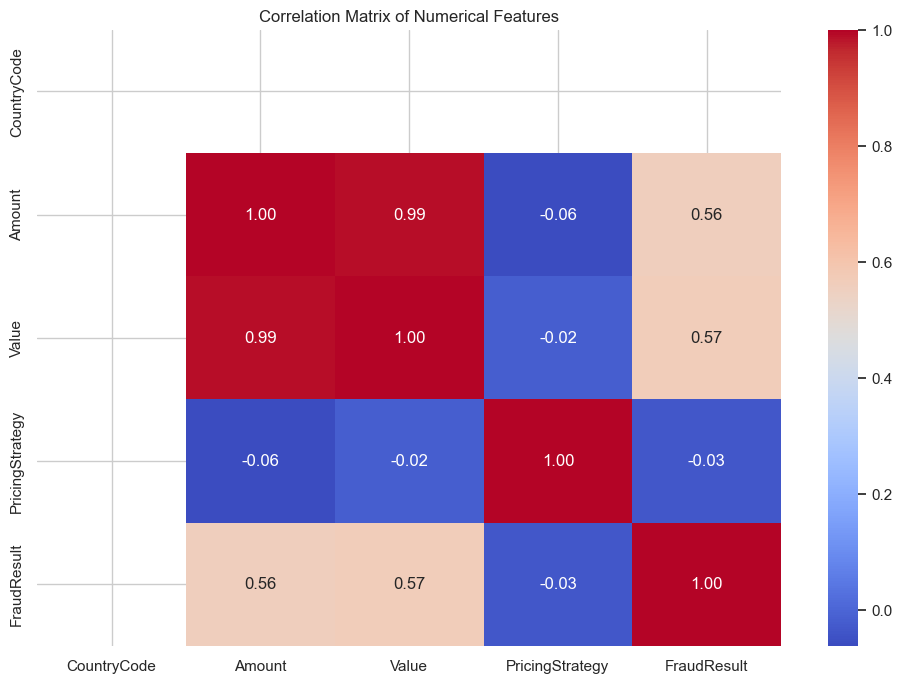

In [10]:
plt.figure(figsize=(12, 8))

correlation_matrix = df[numeric_cols].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

Fraud Result Distribution

In [12]:
df["FraudResult"].value_counts(normalize=True) * 100

FraudResult
0    99.798248
1     0.201752
Name: proportion, dtype: float64

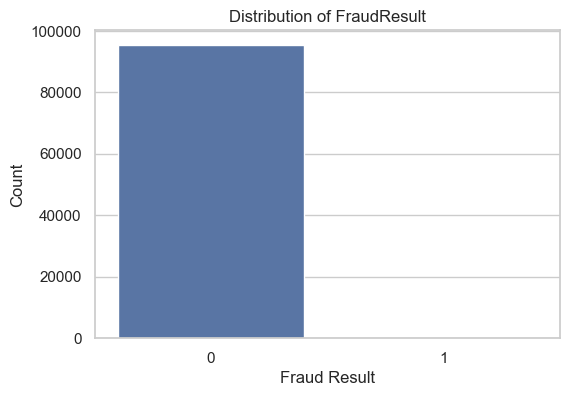

In [13]:
plt.figure(figsize=(6, 4))
sns.countplot(x="FraudResult", data=df)
plt.title("Distribution of FraudResult")
plt.xlabel("Fraud Result")
plt.ylabel("Count")
plt.show()

Customer level Transaction Behaviour

In [14]:
customer_summary = df.groupby("CustomerId").agg(
    total_transaction_amount=("Amount", "sum"),
    average_transaction_amount=("Amount", "mean"),
    transaction_count=("TransactionId", "count"),
    std_transaction_amount=("Amount", "std"),
    total_transaction_value=("Value", "sum")
).reset_index()

customer_summary.head()

,CustomerId,total_transaction_amount,average_transaction_amount,transaction_count,std_transaction_amount,total_transaction_value
0,CustomerId_1,-10000.0,-10000.000000,1,NaN,10000
1,CustomerId_10,-10000.0,-10000.000000,1,NaN,10000
2,CustomerId_1001,20000.0,4000.000000,5,6558.963333,30400
3,CustomerId_1002,4225.0,384.090909,11,560.498966,4775
4,CustomerId_1003,20000.0,3333.333333,6,6030.478146,32000


Top 10 Customers by Transaction count

In [15]:
top_customers = customer_summary.sort_values(
    by="transaction_count",
    ascending=False
).head(10)

top_customers

,CustomerId,total_transaction_amount,average_transaction_amount,transaction_count,std_transaction_amount,total_transaction_value
3478,CustomerId_7343,-104900000.0,-25641.652408,4091,12952.599898,104900000
1969,CustomerId_3634,2628793.0,1260.811990,2085,5388.206928,2726207
3390,CustomerId_647,3633564.0,1944.121990,1869,7715.389537,3905264
66,CustomerId_1096,1949226.0,2486.257653,784,17819.372757,2041334
2271,CustomerId_4033,1768355.5,2272.950514,778,10382.687289,1927834
1494,CustomerId_3066,1119116.0,1828.620915,612,5212.148703,1171282
1072,CustomerId_2528,1695194.3,2779.007049,610,22872.844887,1868148
1224,CustomerId_2728,1250976.6,2134.772355,586,5268.094459,1340378
1504,CustomerId_3078,2438140.0,4255.043630,573,22554.029939,2541260
3605,CustomerId_806,2002972.8,3596.001436,557,38535.621914,2097380


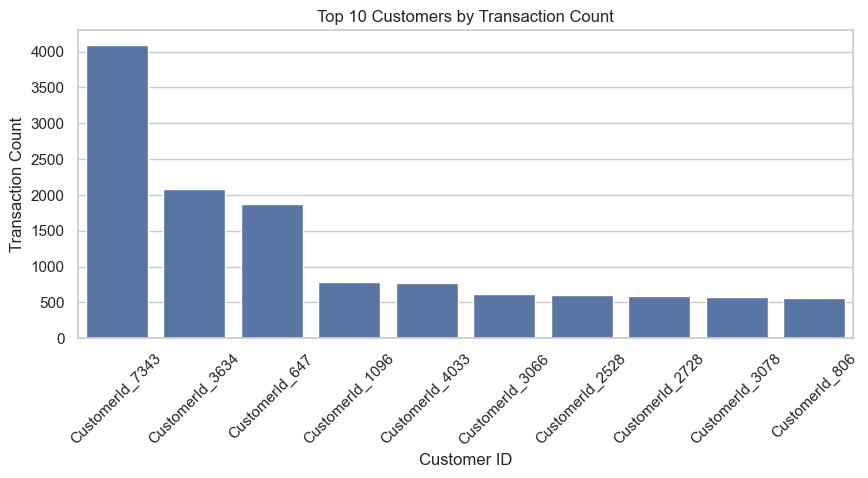

In [16]:
plt.figure(figsize=(10, 4))
sns.barplot(
    data=top_customers,
    x="CustomerId",
    y="transaction_count"
)
plt.title("Top 10 Customers by Transaction Count")
plt.xlabel("Customer ID")
plt.ylabel("Transaction Count")
plt.xticks(rotation=45)
plt.show()

Product Category Analysis

In [17]:
product_category_summary = df.groupby("ProductCategory").agg(
    transaction_count=("TransactionId", "count"),
    total_amount=("Amount", "sum"),
    average_amount=("Amount", "mean")
).sort_values(by="transaction_count", ascending=False)

product_category_summary

,transaction_count,total_amount,average_amount
ProductCategory,,,
financial_services,45405,519231577.5,11435.559465
airtime,45027,37055259.0,822.956426
utility_bill,1920,33087089.0,17232.858854
data_bundles,1613,5487700.0,3402.169870
tv,1279,21284000.0,16641.125880
ticket,216,20886500.0,96696.759259
movies,175,1353500.0,7734.285714
transport,25,4256000.0,170240.000000
other,2,1000.0,500.000000


Data Quality

In [23]:
print("Data Quality Review")

print("-" * 50)

print(
    f"Duplicate Transactions: {df.duplicated().sum()}"
)

print(
    f"Missing Values: {df.isnull().sum().sum()}"
)

print(
    f"Maximum Transaction Amount: {df['Amount'].max():,.2f}"
)

print(
    f"Minimum Transaction Amount: {df['Amount'].min():,.2f}"
)

print(
    f"Transaction Date Range: "
    f"{df['TransactionStartTime'].min()} "
    f"to "
    f"{df['TransactionStartTime'].max()}"
)

Data Quality Review
--------------------------------------------------
Duplicate Transactions: 0
Missing Values: 0
Maximum Transaction Amount: 9,880,000.00
Minimum Transaction Amount: -1,000,000.00
Transaction Date Range: 2018-11-15 02:18:49+00:00 to 2019-02-13 10:01:28+00:00


# EDA Summary: Key Insights and Modeling Hypotheses

## Insight 1: Customer-level aggregation is required

The dataset is transaction-based rather than customer-based. Since credit risk is assessed at the customer level, transactions must be aggregated into customer behavioral profiles.

**Modeling implication:** Create aggregate features such as transaction count, total amount, average amount, and transaction variability.

---

## Insight 2: Transaction amounts exhibit substantial skewness and outliers

Several transactions are significantly larger than the majority of observations.

**Modeling implication:** Apply scaling, robust transformations, and outlier monitoring during feature engineering.

---

## Insight 3: Transaction timing contains behavioral information

Transaction activity varies across hours, days, and months.

**Modeling implication:** Extract temporal features such as transaction hour, day, month, and recency metrics.

---

## Insight 4: Product and channel variables may capture customer behavior

Product categories, providers, and transaction channels show non-uniform distributions.

**Modeling implication:** Encode categorical variables and evaluate their predictive importance.

---

## Insight 5: No default label exists

The dataset does not contain repayment or default outcomes.

**Modeling implication:** Construct a proxy target using RFM segmentation and customer engagement clustering.

---

## Data Quality Considerations

* Extreme transaction amounts should be reviewed for potential outliers.
* Timestamp consistency should be validated before recency calculations.
* Missing values must be handled through a reproducible preprocessing pipeline.
* Customer-level aggregation should be performed carefully to avoid data leakage.
